# Notebook 08 - Comparative Evaluation

**Kelompok 06 - Kecerdasan Buatan 02**

| NPM | Nama |
|-----|------|
| 2306242395 | Calvin Wirathama Katoroy |
| 2306220532 | Syahmi Hamdani |
| 2306220323 | Christover Angelo |
| 2306221024 | Matthew Immanuel |

**Tujuan:** Memuat semua model terlatih (LSTM, GRU, RF) dan menghasilkan tabel perbandingan final, ROC overlay, confusion matrix per model, dan bar chart F1/AUC. Setiap model di-load dengan config terbaiknya dari metrics_summary.csv.

In [96]:
import subprocess, os
from pathlib import Path

REPO_URL  = 'https://github.com/calvinkatoroy/tugas-akhir-ai-kel-06.git'
REPO_NAME = 'tugas-akhir-ai-kel-06'

cwd = Path.cwd()

if (cwd / '../src').resolve().exists():
    result = subprocess.run(['git', '-C', str((cwd / '..').resolve()), 'pull'],
                            capture_output=True, text=True)
    print(result.stdout.strip() or 'Already up to date.')

elif (cwd / 'src').exists():
    result = subprocess.run(['git', 'pull'], capture_output=True, text=True)
    print(result.stdout.strip() or 'Already up to date.')
    os.chdir('notebooks')

else:
    repo_path = cwd / REPO_NAME
    if not repo_path.exists():
        print(f'Cloning {REPO_URL} ...')
        subprocess.run(['git', 'clone', REPO_URL], check=True)
    else:
        print('Repo found, pulling latest...')
        subprocess.run(['git', '-C', str(repo_path), 'pull'], capture_output=True)
    os.chdir(repo_path / 'notebooks')

print(f'Working dir: {Path.cwd()}')

Already up to date.
Working dir: /content/tugas-akhir-ai-kel-06/notebooks


In [97]:
import sys
sys.path.insert(0, "..")

import random
import numpy as np
import pandas as pd
import torch
import yaml
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open("../config.yaml") as f:
    cfg = yaml.safe_load(f)

figures_dir = Path("../results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

In [98]:
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive/tugas-akhir-ai")
    SPLITS_DIR = DRIVE_ROOT / "splits"
else:
    import yaml
    with open("../config.yaml") as f:
        _cfg = yaml.safe_load(f)
    DRIVE_ROOT = Path(_cfg["data"]["drive_root"])
    SPLITS_DIR = Path(_cfg["data"]["splits_drive"])

print(f"DRIVE_ROOT: {DRIVE_ROOT}")
print(f"SPLITS_DIR: {SPLITS_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DRIVE_ROOT: /content/drive/MyDrive/tugas-akhir-ai
SPLITS_DIR: /content/drive/MyDrive/tugas-akhir-ai/splits


In [99]:
# LSTM/GRU use seq splits; RF uses flat splits
X_test_seq  = np.load(SPLITS_DIR / "X_test_seq.npy")
y_test_seq  = np.load(SPLITS_DIR / "y_test_seq.npy")
X_test_flat = np.load(SPLITS_DIR / "X_test.npy")
y_test_flat = np.load(SPLITS_DIR / "y_test.npy")

n_features = X_test_seq.shape[2]
print("Seq test:", X_test_seq.shape, "  Flat test:", X_test_flat.shape)

Seq test: (64698, 10, 16)   Flat test: (64707, 16)


## Load Models

In [100]:
import shutil, copy
from pathlib import Path
import pandas as pd
import torch

ckpt_dir = Path('../results/checkpoints')
ckpt_dir.mkdir(parents=True, exist_ok=True)

for fname in ['best_lstm.pt', 'best_gru.pt', 'best_rf.pkl']:
    src_path = DRIVE_ROOT / fname
    dst_path = ckpt_dir / fname
    if src_path.exists():
        if not dst_path.exists():
            shutil.copy(str(src_path), str(dst_path))
            print(f'Restored {fname} from Drive')
        else:
            print(f'{fname} already local')
    else:
        print(f'WARNING: {fname} not found in Drive - skipping')

_summary = pd.read_csv(str(DRIVE_ROOT / 'metrics_summary.csv'))

def _best_cfg_for(model_name, base_cfg, key_map):
    rows = _summary[_summary['model'] == model_name]
    if rows.empty:
        return copy.deepcopy(base_cfg)

    best = rows.loc[rows['best_val_f1'].idxmax()]
    c = copy.deepcopy(base_cfg)

    for csv_col, (section, key, dtype) in key_map.items():
        if csv_col in best.index and not pd.isna(best[csv_col]):
            c[section][key] = dtype(best[csv_col])
    return c

from src.models.lstm_model import build_lstm
from src.models.gru_model  import build_gru
from src.models.rf_model   import load_rf

_lstm_cfg = _best_cfg_for('LSTM', cfg, {
    'hidden_size': ('lstm', 'hidden_size', int),
    'num_layers':  ('lstm', 'num_layers',  int),
    'dropout':     ('lstm', 'dropout',     float),
})


_lstm_cfg['lstm']['hidden_size'] = 128

lstm = build_lstm(_lstm_cfg, n_features).to(device)
lstm.load_state_dict(torch.load(str(ckpt_dir / 'best_lstm.pt'), map_location=device))
lstm.eval()


_gru_cfg = _best_cfg_for('GRU', cfg, {
    'hidden_size': ('gru', 'hidden_size', int),
    'num_layers':  ('gru', 'num_layers',  int),
    'dropout':     ('gru', 'dropout',     float),
})


_gru_cfg['gru']['hidden_size'] = 128

gru = build_gru(_gru_cfg, n_features).to(device)
gru.load_state_dict(torch.load(str(ckpt_dir / 'best_gru.pt'), map_location=device))
gru.eval()


rf = load_rf(str(ckpt_dir / 'best_rf.pkl'))

print('All models loaded.')

best_lstm.pt already local
best_gru.pt already local
best_rf.pkl already local
All models loaded.


## Per-Model Evaluation


=== LSTM  -  Classification Report ===
              precision    recall  f1-score   support

      normal       0.99      1.00      0.99     14672
        ddos       1.00      1.00      1.00     50026

    accuracy                           1.00     64698
   macro avg       0.99      1.00      0.99     64698
weighted avg       1.00      1.00      1.00     64698



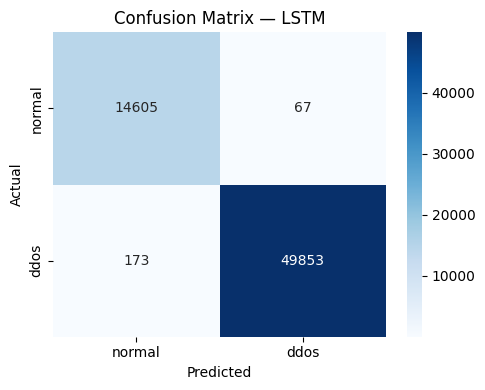

  FPR=0.0046  ROC-AUC=0.9996

=== GRU  -  Classification Report ===
              precision    recall  f1-score   support

      normal       0.99      1.00      0.99     14672
        ddos       1.00      1.00      1.00     50026

    accuracy                           1.00     64698
   macro avg       0.99      1.00      0.99     64698
weighted avg       1.00      1.00      1.00     64698



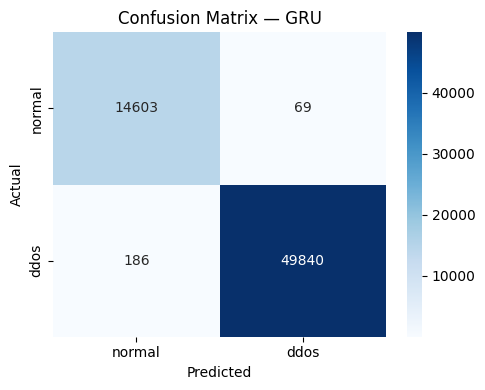

  FPR=0.0047  ROC-AUC=0.9995

=== RandomForest  -  Classification Report ===
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     14675
        ddos       1.00      1.00      1.00     50032

    accuracy                           1.00     64707
   macro avg       1.00      1.00      1.00     64707
weighted avg       1.00      1.00      1.00     64707



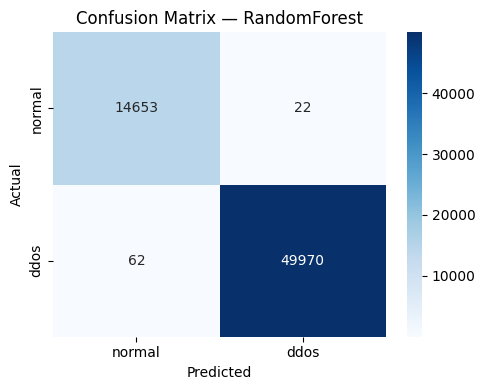

  FPR=0.0015  ROC-AUC=0.9998


In [101]:
from src.evaluate import evaluate_dl_model, evaluate_rf_model
from sklearn.metrics import roc_curve, auc

_, y_prob_lstm = evaluate_dl_model(
    lstm, X_test_seq, y_test_seq, model_name='LSTM',
    figures_dir='../results/figures', csv_path=str(DRIVE_ROOT / "metrics_summary.csv"))

_, y_prob_gru = evaluate_dl_model(
    gru, X_test_seq, y_test_seq, model_name='GRU',
    figures_dir='../results/figures', csv_path=str(DRIVE_ROOT / "metrics_summary.csv"))
_, y_prob_rf = evaluate_rf_model(
    rf, X_test_flat, y_test_flat,
    figures_dir='../results/figures', csv_path=str(DRIVE_ROOT / "metrics_summary.csv"))

## ROC Curve Overlay


=== LSTM  -  Classification Report ===
              precision    recall  f1-score   support

      normal       0.99      1.00      0.99     14672
        ddos       1.00      1.00      1.00     50026

    accuracy                           1.00     64698
   macro avg       0.99      1.00      0.99     64698
weighted avg       1.00      1.00      1.00     64698



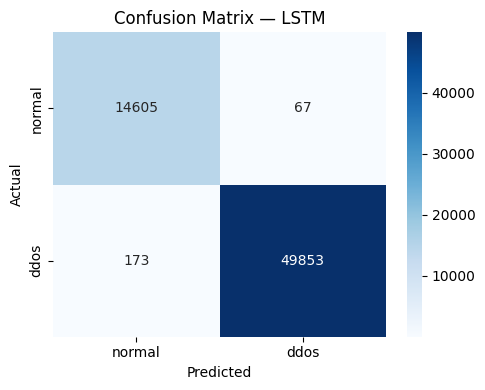

  FPR=0.0046  ROC-AUC=0.9996

=== GRU  -  Classification Report ===
              precision    recall  f1-score   support

      normal       0.99      1.00      0.99     14672
        ddos       1.00      1.00      1.00     50026

    accuracy                           1.00     64698
   macro avg       0.99      1.00      0.99     64698
weighted avg       1.00      1.00      1.00     64698



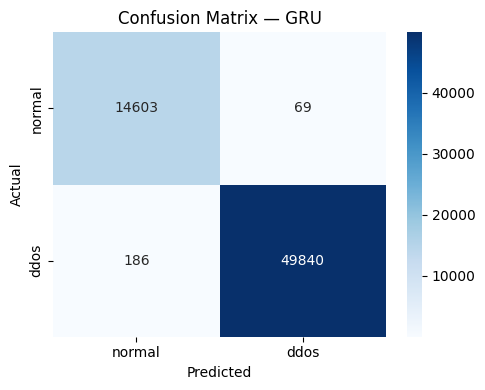

  FPR=0.0047  ROC-AUC=0.9995

=== RandomForest  -  Classification Report ===
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     14675
        ddos       1.00      1.00      1.00     50032

    accuracy                           1.00     64707
   macro avg       1.00      1.00      1.00     64707
weighted avg       1.00      1.00      1.00     64707



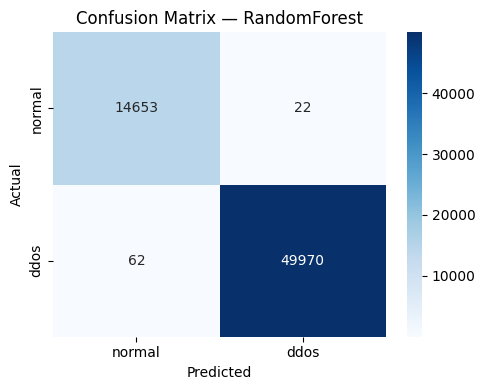

  FPR=0.0015  ROC-AUC=0.9998


In [102]:
from src.evaluate import evaluate_dl_model, evaluate_rf_model
from sklearn.metrics import roc_curve, auc

_, y_prob_lstm = evaluate_dl_model(
    lstm, X_test_seq, y_test_seq, model_name='LSTM',
    figures_dir='../results/figures',
    csv_path=str(DRIVE_ROOT / "metrics_summary.csv")
)

_, y_prob_gru = evaluate_dl_model(
    gru, X_test_seq, y_test_seq, model_name='GRU',
    figures_dir='../results/figures',
    csv_path=str(DRIVE_ROOT / "metrics_summary.csv")
)

_, y_prob_rf = evaluate_rf_model(
    rf, X_test_flat, y_test_flat,
    figures_dir='../results/figures',
    csv_path=str(DRIVE_ROOT / "metrics_summary.csv")
)

## Final Comparison Table

In [103]:
import pandas as pd, os

csv_path = str(DRIVE_ROOT / 'metrics_summary.csv')

try:
    summary = pd.read_csv(csv_path)
except Exception:
    print('WARNING: could not read metrics_summary.csv')
    summary = pd.DataFrame()

# Keep only final test-set evaluation rows (have roc_auc filled)
test_rows = summary[
    summary['model'].isin(['LSTM', 'GRU', 'RandomForest'])
].copy()

test_rows = test_rows.dropna(subset=['roc_auc'])

display_cols = [
    'model',
    'accuracy',
    'precision_ddos',
    'recall_ddos',
    'f1_ddos',
    'fpr',
    'roc_auc'
]

final_table = (
    test_rows[display_cols]
    .drop_duplicates(subset='model')
    .set_index('model')
)

print(final_table.to_string())

final_table.to_csv('../results/final_comparison.csv')

print('\nSaved to results/final_comparison.csv')

              accuracy  precision_ddos  recall_ddos  f1_ddos     fpr  roc_auc
model                                                                        
LSTM            0.9963          0.9987       0.9965   0.9976  0.0046   0.9996
RandomForest    0.9987          0.9996       0.9988   0.9992  0.0015   0.9998
GRU             0.9961          0.9992       0.9958   0.9975  0.0028   0.9996

Saved to results/final_comparison.csv


## Hyperparameter Tuning Summary

In [104]:
dl_cols = [c for c in ['exp_id', 'hidden_size', 'd_model', 'num_filters', 'num_layers', 'dropout', 'best_val_f1', 'notes'] if c in summary.columns]
rf_cols  = [c for c in ['exp_id', 'best_val_f1', 'notes'] if c in summary.columns]

for model_name in ['LSTM', 'GRU']:
    print(f"=== {model_name} experiments ===")
    subset = summary[summary['model'] == model_name]
    avail = [c for c in dl_cols if c in subset.columns]
    print(subset[avail].to_string(index=False))
    print()

print("=== RF experiments ===")
print(summary[summary['model'] == 'RandomForest'][rf_cols].to_string(index=False))

=== LSTM experiments ===
           exp_id  hidden_size  num_layers  dropout  best_val_f1                      notes
 lstm_01_baseline        128.0         2.0      0.3       0.9976 baseline - config defaults
 lstm_02_hidden64         64.0         2.0      0.3       0.9976             hidden_size=64
 lstm_01_baseline        128.0         2.0      0.3       0.9974 baseline - config defaults
 lstm_02_hidden64         64.0         2.0      0.3       0.9977             hidden_size=64
lstm_03_hidden256        256.0         2.0      0.3       0.9975            hidden_size=256
  lstm_04_layers3        128.0         3.0      0.3       0.9976               num_layers=3
lstm_05_dropout05        128.0         2.0      0.5       0.9974                dropout=0.5
  lstm_06_seqlen5        128.0         2.0      0.3       0.9974                  seq_len=5
 lstm_01_baseline        128.0         2.0      0.3       0.9976 baseline - config defaults
              NaN          NaN         NaN      NaN    

## Bar Chart - F1 / AUC Comparison

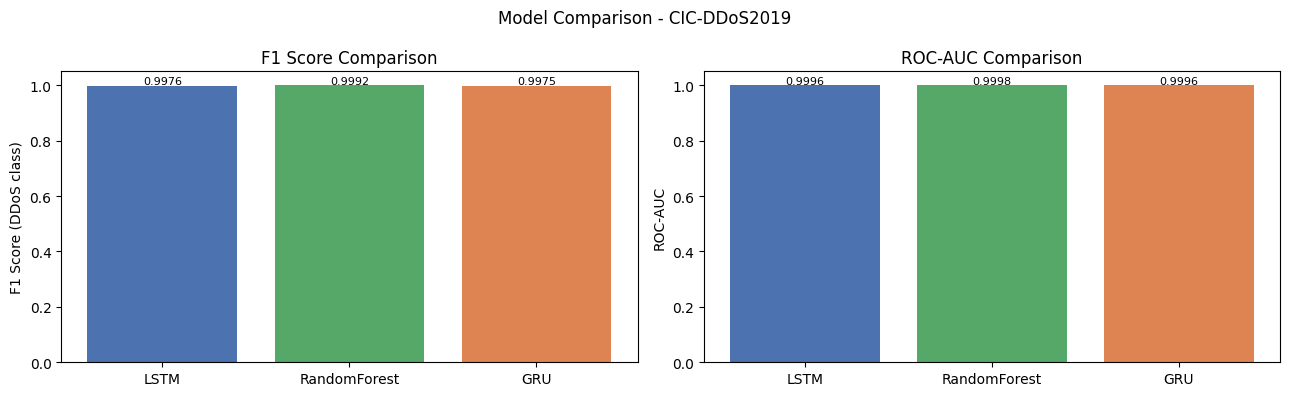

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

models = final_table.index.tolist()
colors = ['#4C72B0', '#55A868', '#DD8452']

axes[0].bar(models, final_table['f1_ddos'], color=colors[:len(models)])
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('F1 Score (DDoS class)')
axes[0].set_title('F1 Score Comparison')
for i, v in enumerate(final_table['f1_ddos']):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=8)

axes[1].bar(models, final_table['roc_auc'], color=colors[:len(models)])
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC Comparison')
for i, v in enumerate(final_table['roc_auc']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=8)

plt.suptitle('Model Comparison - CIC-DDoS2019', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/model_comparison_bar.png', dpi=150)
plt.show()